# Doğrusal Regresyon Testleri

Bu notebook, doğrusal regresyon algoritmasının temel kavramlarını ve gradient descent (dereceli alçalma) optimizasyon tekniğini uygulamalı olarak göstermektedir. Bu çalışma, *Doğrusal Regresyon* ders notlarındaki teorik kavramları pratiğe dökmektedir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

`np.linspace()` fonksiyonu, belirtilen başlangıç ve bitiş değerleri arasında, istenen sayıda eşit aralıklı değer üretmek için kullanılır. Bu, özellikle bir aralık boyunca düzenli olarak dağılmış veri noktaları oluşturmak istediğimizde kullanışlıdır.

Düz bir array (`np.array([5, 6, 7, ...])`) ile de benzer bir sonuç elde edilebilir, ancak `np.linspace()` şu avantajları sunar:
1.  **Kolaylık:** Başlangıç, bitiş ve nokta sayısını belirterek kolayca dizi oluşturulur. Özellikle çok sayıda nokta gerektiğinde manuel olarak yazmaktan daha pratiktir.
2.  **Kontrol:** Aralık ve nokta sayısı üzerinde hassas kontrol sağlar. Bu, verinin dağılımını istediğimiz gibi ayarlamamıza olanak tanır.
3.  **Okunabilirlik:** Kodun amacı daha net anlaşılır; belirli bir aralıkta eşit aralıklı değerler üretildiği bellidir.

Bu örnekte, 5 ile 14 metrekare arasında, eşit aralıklarla 10 farklı ev alanı değeri oluşturmak için `np.linspace()` kullanılmıştır. Bu, doğrusal regresyonun nasıl çalıştığını göstermek için kontrollü ve anlaşılır bir veri seti sağlar.


In [9]:
X = np.linspace(5, 14, 10)
dummy = np.linspace(1, 2, 5)
print(X)
print(dummy)

[ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
[1.   1.25 1.5  1.75 2.  ]


Şimdi, oluşturduğumuz X değerlerini kullanarak hedef değişkenimiz olan y'yi (ev fiyatı) oluşturacağız. Bu örnekte basit bir doğrusal ilişki kullanıyoruz: `y = 2 * X`. Yani her metrekare için fiyat 2 birim artmaktadır.

In [10]:
y = 2 * X
print(y)

[10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]


## Veri Görselleştirme

Oluşturduğumuz veriyi görselleştirelim. Aşağıdaki grafik, ev alanı (X) ve fiyat (y) arasındaki ilişkiyi göstermektedir.

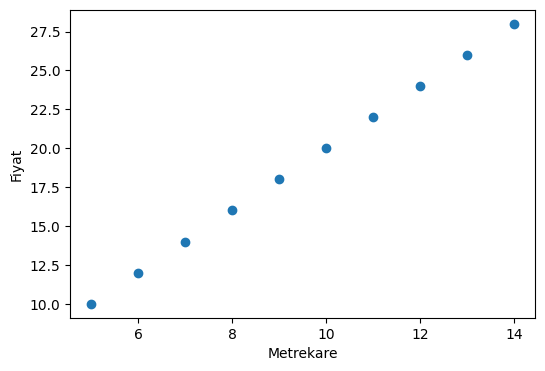

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(X, y)
plt.ylabel("Fiyat")
plt.xlabel("Metrekare")
plt.show()

## Model Tahmini

Şimdi basit bir model oluşturalım ve tahminler yapalım. İlk olarak theta (t1) değerimizi 1 olarak başlatacağız. Gerçek değer 2 olduğu için modelimiz eksik tahmin yapacaktır.

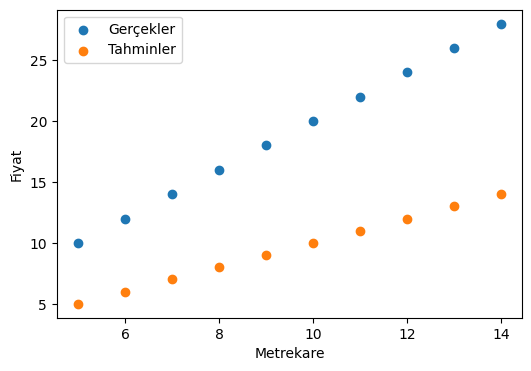

In [16]:
t1 = 1
y_hat = t1 * X
plt.figure(figsize=(6, 4))
plt.scatter(X, y, label="Gerçekler")
plt.scatter(X, y_hat, label="Tahminler")
plt.ylabel("Fiyat")
plt.xlabel("Metrekare")
plt.legend()
plt.show()

Veri setimizin boyutunu kontrol edelim:

In [17]:
len(X)

10

## Hata (Cost) Fonksiyonu

Modelimizin performansını değerlendirmek için Mean Squared Error (MSE) hata fonksiyonunu kullanacağız. Bu, tahminlerimiz ile gerçek değerler arasındaki farkların karelerinin ortalamasıdır.

$$J(\theta_1) = \frac{1}{2m} \sum_{i=1}^m (\theta_1 x^{(i)} - y^{(i)})^2$$

Burada m örnek sayısı, $\theta_1$ modelimizin parametresidir.

In [18]:
np.sum((y_hat - y) ** 2) / (2 * len(X))

np.float64(49.25)

## Farklı Theta Değerleri için Hata Fonksiyonu

Şimdi farklı theta değerleri için hata fonksiyonunu hesaplayalım ve görselleştirelim. Bu, hata fonksiyonunun konveks yapısını görmemizi sağlayacaktır.

In [22]:
thetalar = np.linspace(-10, 10, 31)
hatalar = []
for theta in thetalar:
    y_hat = theta * X
    hata = np.sum((y_hat - y) ** 2) / (2 * len(X))
    hatalar.append(hata)
    print(f"Theta değeri: {theta:.2f}, Hata: {hata:.2f}") # python f-string

Theta değeri: -10.00, Hata: 7092.00
Theta değeri: -9.33, Hata: 6325.89
Theta değeri: -8.67, Hata: 5603.56
Theta değeri: -8.00, Hata: 4925.00
Theta değeri: -7.33, Hata: 4290.22
Theta değeri: -6.67, Hata: 3699.22
Theta değeri: -6.00, Hata: 3152.00
Theta değeri: -5.33, Hata: 2648.56
Theta değeri: -4.67, Hata: 2188.89
Theta değeri: -4.00, Hata: 1773.00
Theta değeri: -3.33, Hata: 1400.89
Theta değeri: -2.67, Hata: 1072.56
Theta değeri: -2.00, Hata: 788.00
Theta değeri: -1.33, Hata: 547.22
Theta değeri: -0.67, Hata: 350.22
Theta değeri: 0.00, Hata: 197.00
Theta değeri: 0.67, Hata: 87.56
Theta değeri: 1.33, Hata: 21.89
Theta değeri: 2.00, Hata: 0.00
Theta değeri: 2.67, Hata: 21.89
Theta değeri: 3.33, Hata: 87.56
Theta değeri: 4.00, Hata: 197.00
Theta değeri: 4.67, Hata: 350.22
Theta değeri: 5.33, Hata: 547.22
Theta değeri: 6.00, Hata: 788.00
Theta değeri: 6.67, Hata: 1072.56
Theta değeri: 7.33, Hata: 1400.89
Theta değeri: 8.00, Hata: 1773.00
Theta değeri: 8.67, Hata: 2188.89
Theta değeri: 9.3

Hata fonksiyonu grafiğini çizelim. Grafikten, hata fonksiyonunun minimum noktasının $\theta_1 = 2$ civarında olduğunu görebiliriz.

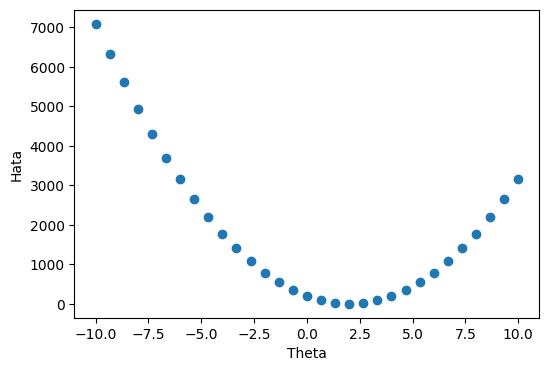

In [23]:

plt.figure(figsize=(6, 4))
plt.scatter(thetalar, hatalar)
plt.ylabel("Hata")
plt.xlabel("Theta")
plt.show()

## Gradient Descent (Dereceli Alçalma)

Şimdi, gradient descent algoritması ile modelimizin parametrelerini optimize edeceğiz. İlk olarak verileri ve başlangıç değerlerini yeniden tanımlayalım.

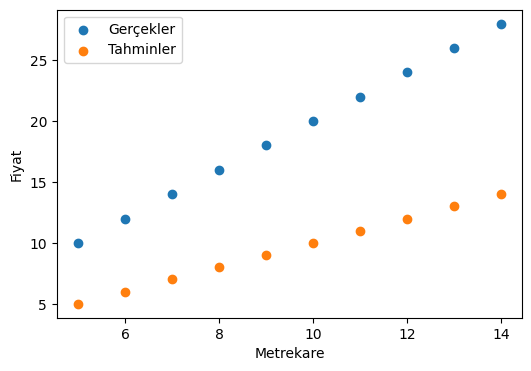

In [25]:

X = np.linspace(5, 14, 10)
y = 2 * X


t1 = 1
y_hat = t1 * X
plt.figure(figsize=(6, 4))
plt.scatter(X, y, label="Gerçekler")
plt.scatter(X, y_hat, label="Tahminler")
plt.ylabel("Fiyat")
plt.xlabel("Metrekare")
plt.legend()
plt.show()


### Tek Bir Gradient Adımı

Gradient descent'in tek bir iterasyonunu uygulayalım. Gradient (türev) formülü şöyledir:

$$\frac{\partial}{\partial\theta_1}J(\theta_1) = \frac{1}{m}\sum_{i=1}^m (\theta_1 x^{(i)} - y^{(i)}) x^{(i)}$$

Ve güncelleme kuralı:

$$\theta_1 := \theta_1 - \alpha \frac{\partial}{\partial\theta_1}J(\theta_1)$$

Burada $\alpha$ öğrenme hızıdır (learning rate).

In [26]:
t1 = t1 - 0.001 * np.sum((y_hat - y) * X) / (len(X))
print(t1)

1.0985


### Tam Gradient Descent Algoritması

Şimdi birden fazla iterasyon ile gradient descent'i uygulayalım. Her adımda theta değerini ve hata değerini yazdıracağız.

In [ ]:
X = np.linspace(5, 14, 10)
y = 2 * X
t1 = 1
learning_rate = 0.001
for _ in range(100):
    y_hat = t1 * X
    hata = np.sum((y_hat - y) ** 2) / (2 * len(X))
    gradient = np.sum((y_hat - y) * X) / (len(X))
    ## this is the derivative of the cost function
    t1 = t1 - learning_rate * gradient
    print(f"t: {t1:.3f}, loss: {hata:.3f}")

X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.099, loss: 49.250
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.187, loss: 40.026
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.267, loss: 32.529
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.340, loss: 26.436
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.405, loss: 21.485
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.463, loss: 17.461
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.516, loss: 14.190
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
y is  [10. 12. 14. 16. 18. 20. 22. 24. 26. 28.]
t: 1.564, loss: 11.533
X is  [ 5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]


### Öğrenme Hızı (Learning Rate) Seçimi Üzerine Not

Yukarıdaki örnekte `learning_rate = 0.001` gibi sabit bir değer kullandık. Gerçek dünya uygulamalarında öğrenme hızı ($\alpha$) seçimi önemlidir ve genellikle şu yöntemlerle ele alınır:

1.  **Sabit Değer ve Deneme:** Başlangıçta yaygın kullanılan değerlerden biri (örn. 0.1, 0.01, 0.001) seçilir ve modelin performansı gözlemlenir. Farklı sabit değerler denenerek en iyisi bulunmaya çalışılır.
2.  **Hiperparametre Optimizasyonu:** Farklı öğrenme hızları sistematik olarak denenir (Grid Search, Random Search gibi) ve bir doğrulama (validation) setinde en iyi performansı veren değer seçilir.
3.  **Öğrenme Hızı Zamanlaması (Learning Rate Scheduling):** Eğitim ilerledikçe öğrenme hızı belirli bir kurala göre azaltılır. Örneğin, her 10 epoch'ta bir öğrenme hızını yarıya indirmek gibi. Bu, başlangıçta hızlı yakınsama sağlarken, optimuma yaklaştıkça daha hassas adımlar atılmasına olanak tanır.
4.  **Uyarlanabilir Öğrenme Hızı Algoritmaları:** Adam, RMSprop, AdaGrad gibi modern optimizasyon algoritmaları, her parametre için öğrenme hızını eğitimin gidişatına göre otomatik olarak ayarlar. Bu yöntemler genellikle daha az manuel ayar gerektirir ve karmaşık problemler için tercih edilir.

Öğrenme hızının rastgele bir dağılımdan seçilmesi yaygın bir uygulama değildir. Değerin seçimi, modelin yakınsama hızını ve sonucun kalitesini doğrudan etkiler. Çok yüksek bir değer ıraksamaya (divergence), çok düşük bir değer ise çok yavaş eğitime veya kötü yerel minimumlara takılmaya neden olabilir.

## Gürültülü Örnekler

Gerçek dünya verileri genellikle gürültülüdür. Şimdi, daha gerçekçi bir veri seti oluşturmak için verimize rastgele gürültü ekleyelim ve modelimizi bu veri üzerinde eğitelim.

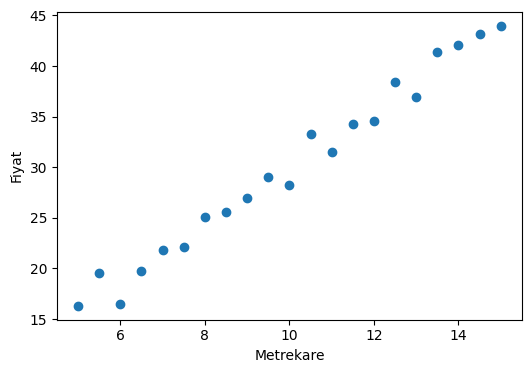

In [32]:
X = np.linspace(5, 15, 21)
y = 3 * X + np.random.randn(len(X))
plt.figure(figsize=(6, 4))
plt.scatter(X, y)
plt.ylabel("Fiyat")
plt.xlabel("Metrekare")
plt.show()

### Gürültülü Veri ile Eğitim

Gürültülü verimizi kullanarak modeli eğitelim. Burada daha yüksek bir öğrenme hızı kullanıyoruz ve theta değerimizi farklı bir noktadan (-3) başlatıyoruz.

In [39]:
t1 = -3
learning_rate = 0.01
for _ in range(100):
    y_hat = t1 * X
    hata = np.sum((y_hat - y) ** 2) / (2 * len(X))
    gradient = np.sum((y_hat - y) * X) / (len(X))
    t1 = t1 - learning_rate * gradient
    print(f"t: {t1:.3f}, loss: {hata:.3f}")

t: 3.539, loss: 1959.088
t: 2.939, loss: 17.250
t: 2.994, loss: 0.933
t: 2.989, loss: 0.796
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.990, loss: 0.795
t: 2.9

### Sonuç Görselleştirme

Eğitilmiş modelimizin tahminlerini gerçek değerlerle karşılaştıralım. Gradient descent algoritması, gürültülü veri setimiz üzerinde $\theta_1$ değerini yaklaşık 3'e yaklaştırmıştır, ki bu gerçek değerimize oldukça yakındır.

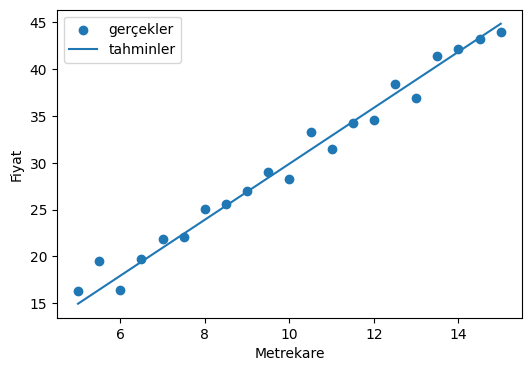

In [40]:
plt.figure(figsize=(6, 4))
plt.scatter(X, y, label="gerçekler")
plt.plot(X, y_hat, label="tahminler")
plt.ylabel("Fiyat")
plt.xlabel("Metrekare")
plt.legend()
plt.show()